## Análise Exploratória dos Dados

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math
from statsmodels.tsa.stattools import adfuller

### Carregamento dos Dados

In [13]:
# 1. Carregamento com tratamento de índice
caminho = "/home/hermann/projeto_soft_sensor/data/raw/debutanizer_data.txt"

data = np.loadtxt(caminho, skiprows=5)

df = pd.DataFrame(data)

# 2. Renomeação correta seguindo a ordem (y, x1, x2, x3, x4, x5, x6, x7)

df.columns = [

    'Top_Temp',   # x1
    'Top_Pressure',    # x2
    'Reflux_Flow', # x3
    'Flow_To_Next_Process', # x4
    'Temp_Sixth_Tray',# x5
    'Bottom_Temp_1', # x6
    'Bottom_Temp_2',  # x7
    'C4_Fundo',     # y
]

df

,Top_Temp,Top_Pressure,Reflux_Flow,Flow_To_Next_Process,Temp_Sixth_Tray,Bottom_Temp_1,Bottom_Temp_2,C4_Fundo
0,0.268900,0.650894,0.832742,0.583420,0.784759,0.843079,0.822079,0.180295
1,0.268483,0.650140,0.852153,0.577510,0.776487,0.838605,0.822079,0.177124
2,0.267967,0.659657,0.823618,0.571600,0.764546,0.807879,0.786246,0.173618
3,0.267451,0.668338,0.808371,0.565689,0.752605,0.799606,0.786246,0.171640
4,0.266935,0.647191,0.761948,0.559779,0.745326,0.773122,0.746142,0.166972
...,...,...,...,...,...,...,...,...
2389,0.284859,0.645894,0.688723,0.355109,0.615583,0.608848,0.500866,0.188976
2390,0.266139,0.665503,0.665640,0.354275,0.588834,0.582074,0.508999,0.178992
2391,0.247419,0.665706,0.664740,0.353441,0.561301,0.602186,0.523348,0.169742
2392,0.228699,0.672975,0.677300,0.352607,0.530730,0.636970,0.537697,0.159023


### Visualização dos dados medidos pelos sensores

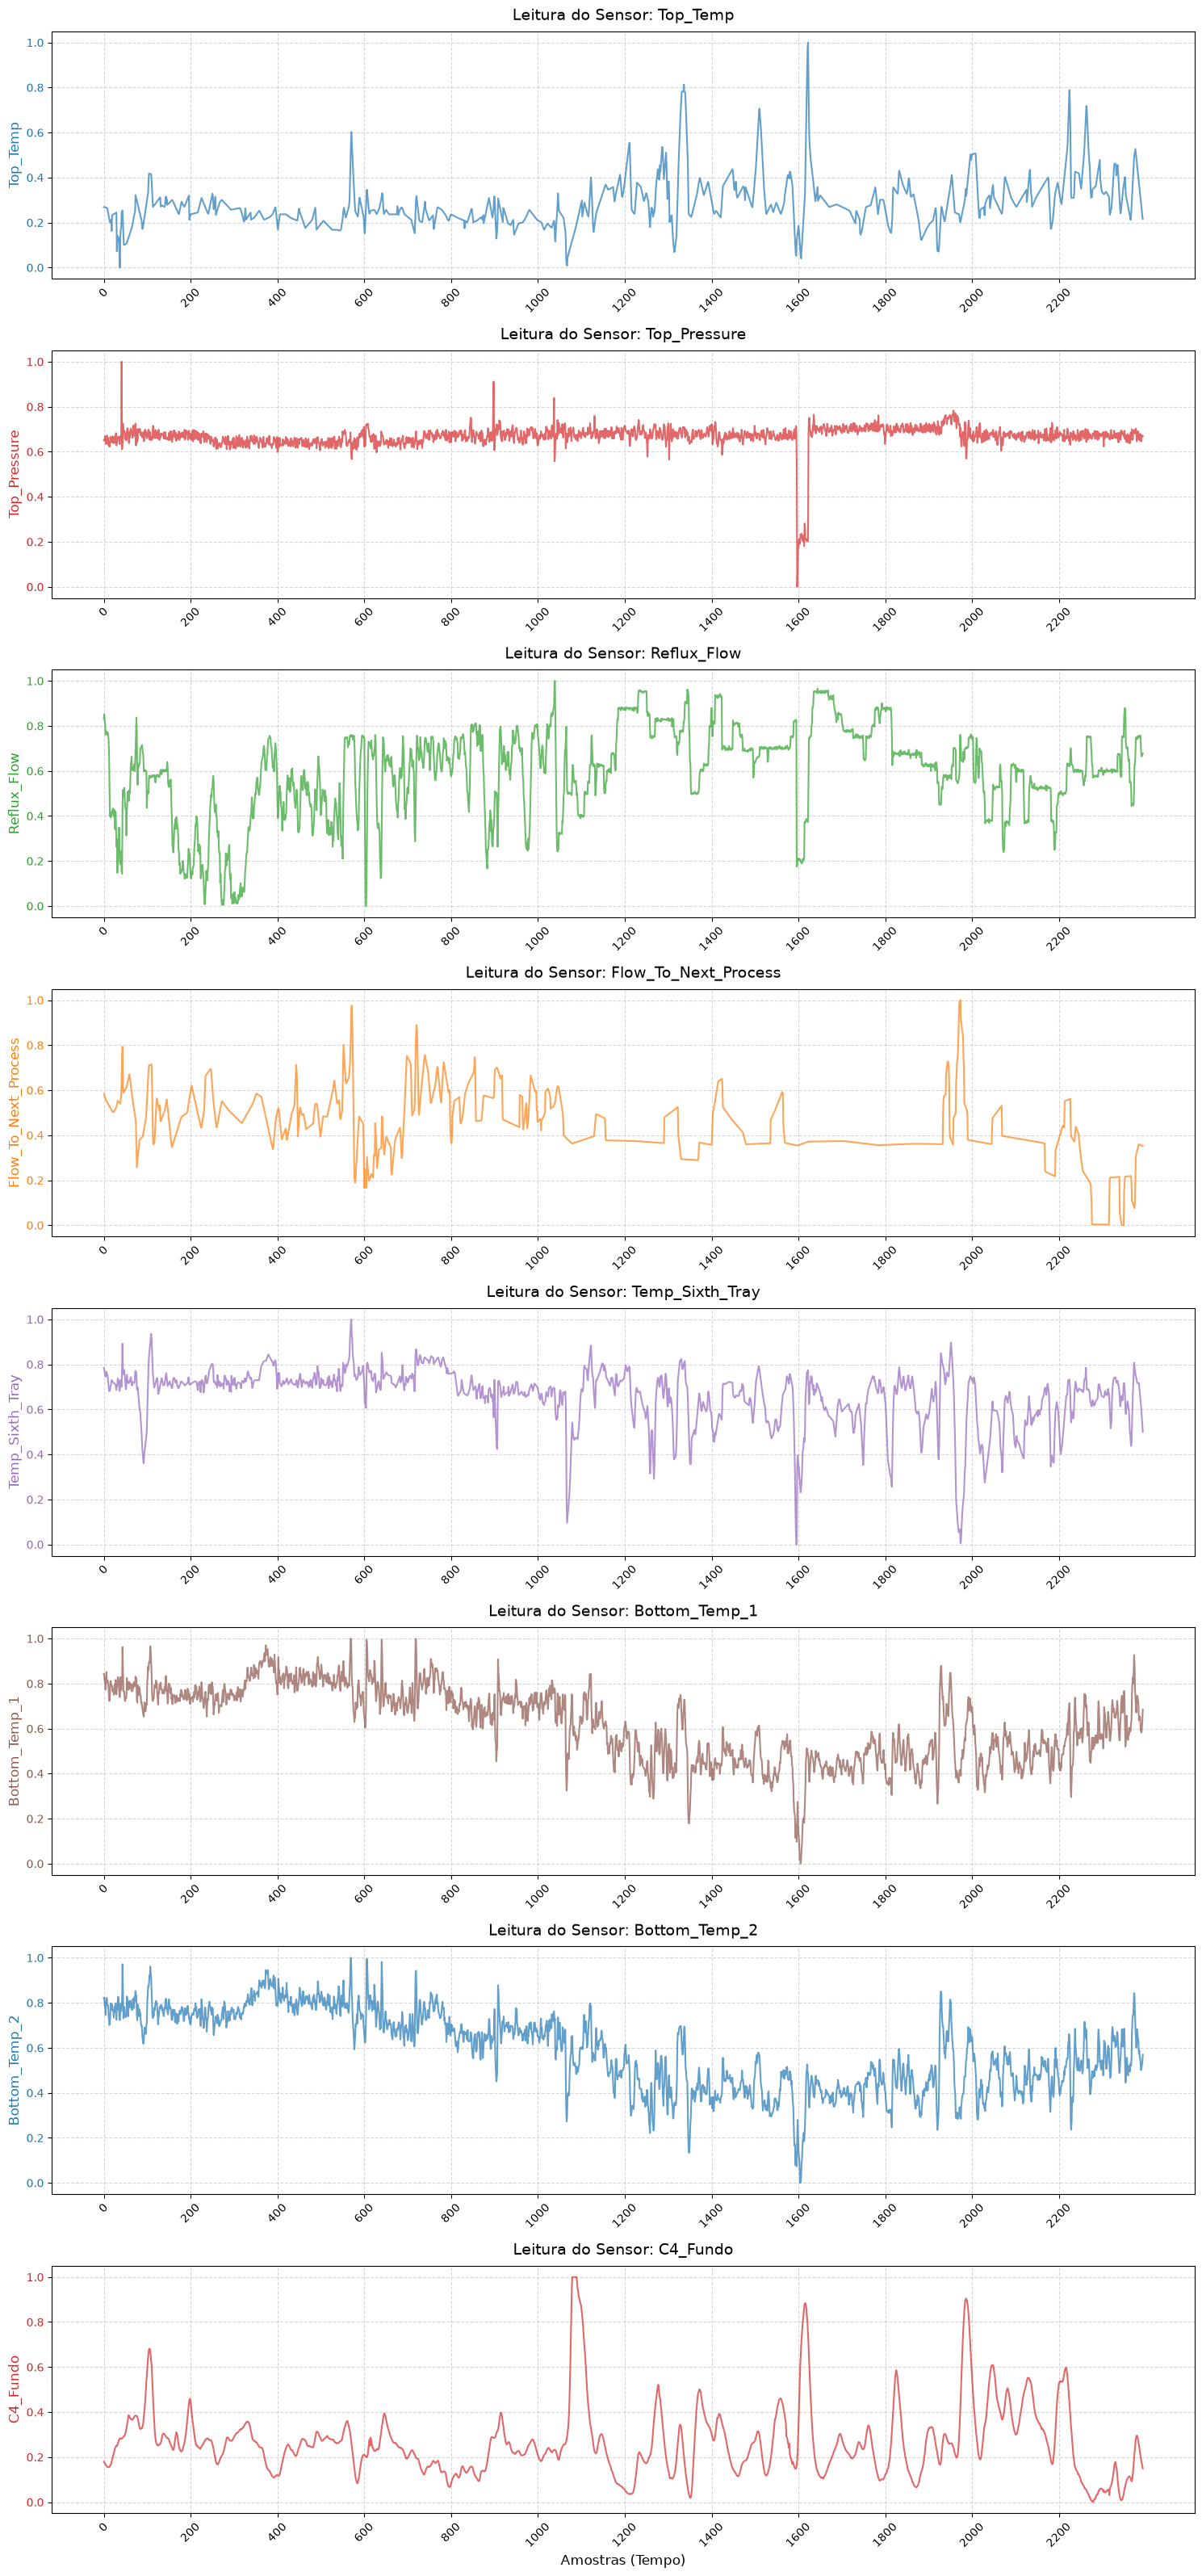

In [14]:
# Definimos o número de linhas de subplots baseado na quantidade de colunas do DataFrame
num_colunas = len(df.columns)

# Criando a figura dinamicamente compartilhando o eixo X

fig, axes = plt.subplots(num_colunas, 1, figsize=(15, 4 * num_colunas), sharex=True)

# Esse ajuste garante que 'axes' seja sempre uma lista iterável.
if num_colunas == 1:
    axes = [axes]

# Lista de cores 
cores = ['tab:blue', 'tab:red', 'tab:green', 'tab:orange', 'tab:purple', 'tab:brown']

# Loop para construir cada gráfico
for i, col in enumerate(df.columns):
    ax = axes[i]
    cor_atual = cores[i % len(cores)] 

    # Plotagem dos dados
    ax.plot(df.index, df[col], color=cor_atual, alpha=0.7, label=col)

    # Customização de cada subplot
    ax.set_ylabel(col, color=cor_atual, fontsize=12)
    ax.tick_params(axis='y', labelcolor=cor_atual)
    ax.set_title(f"Leitura do Sensor: {col}", fontsize=14, pad=10)
    ax.grid(True, linestyle='--', alpha=0.5)

    # Exibição dos ticks e rótulos no eixo X para TODOS os subplots
    ax.set_xticks(df.index[::200])
    ax.xaxis.set_tick_params(labelbottom=True, rotation=45)

# Configuração do nome do eixo X apenas no último gráfico para fechar o layout
axes[-1].set_xlabel('Amostras (Tempo)', fontsize=12)

plt.tight_layout()
plt.show()

Vamos dar um zoom ao redor do tempo 1600 e analisar o intervalo:

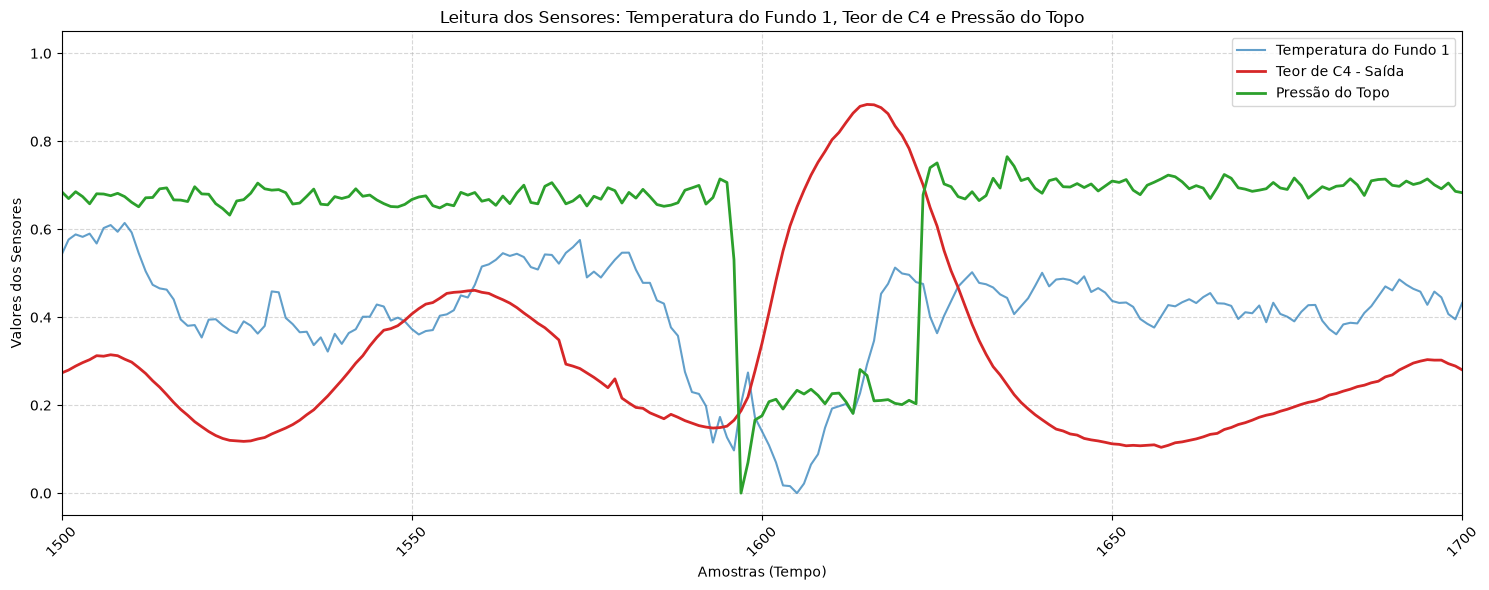

In [22]:
fig, ax = plt.subplots(figsize=(15,6))

# ----------------------------------------------------
# Plotando todas as curvas no mesmo eixo (ax)
# ----------------------------------------------------
# Curva 1: Temperatura do Topo
ax.plot(df.index, df['Bottom_Temp_1'], color='tab:blue', alpha=0.7, label='Temperatura do Fundo 1')

# Curva 2: Teor de C4
ax.plot(df.index, df['C4_Fundo'], color='tab:red', linewidth=2, label='Teor de C4 - Saída')

# Curva 3: Pressão do Topo
ax.plot(df.index, df['Top_Pressure'], color='tab:green', linewidth=2, label='Pressão do Topo')

# Configurações do eixo principal
ax.set_xlabel('Amostras (Tempo)')
ax.set_ylabel('Valores dos Sensores')
ax.set_title("Leitura dos Sensores: Temperatura do Fundo 1, Teor de C4 e Pressão do Topo")
ax.grid(True, linestyle='--', alpha=0.5)

# Adiciona a legenda para identificar qual cor pertence a qual curva
ax.legend(loc='upper right')

# ====================================================
#  DEFININDO O INTERVALO DE VISUALIZAÇÃO (ZOOM)
# ====================================================
inicio = 1500   # Substitua pelo índice inicial desejado
fim = 1700     # Substitua pelo índice final desejado

# Define o limite do zoom no eixo X
ax.set_xlim(inicio, fim)

# Ajustando a frequência dos ticks e rotação
ax.set_xticks(range(inicio, fim + 1, 50))
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

É possível verificar que várias leituras de sensores reduzem abruptamente por volta do tempo 1600, enquanto o $C_4$ no fundo aumenta, ocasionando a perda de capacidade de fracionamento. Uma das hipóteses é que pode ter havido uma parada na planta, ou uma queda de carga térmica no Refervedor, causando a seguinte dinâmica:

- Queda de Carga Térmica (Refervedor): Se a temperatura do fundo ou das bandejas intermediárias cai, a coluna perde energia para vaporizar os componentes mais leves (como o butano).
- Efeito na Composição das Correntes: Sem energia térmica suficiente para subir em forma de vapor em direção ao topo, o butano acaba condensando e "escorrendo" junto com o produto de fundo.
- Resultado: A temperatura cai (sensores reduzem seus valores) e, consequentemente, a corrente de fundo fica "contaminada" com componentes mais leves, fazendo o teor de $C_4$ disparar (sensor do cromatógrafo aumenta).

Podemos ainda verificar que os valores lidos pelos sensores de processo começam a cair alguns passos antes da leitura do cromatógrafo começar a subir, o que evidencia o atraso na dinâmica do processo, ou seja, o tempo "morto" que a composição de C4 no fundo leva para ser alterada quando há uma perturbação em alguma das variáveis do processo.

### Matriz de Correlação (dados brutos)

Vamos agora analisar a correlação entre as diferentes variáveis do processo:

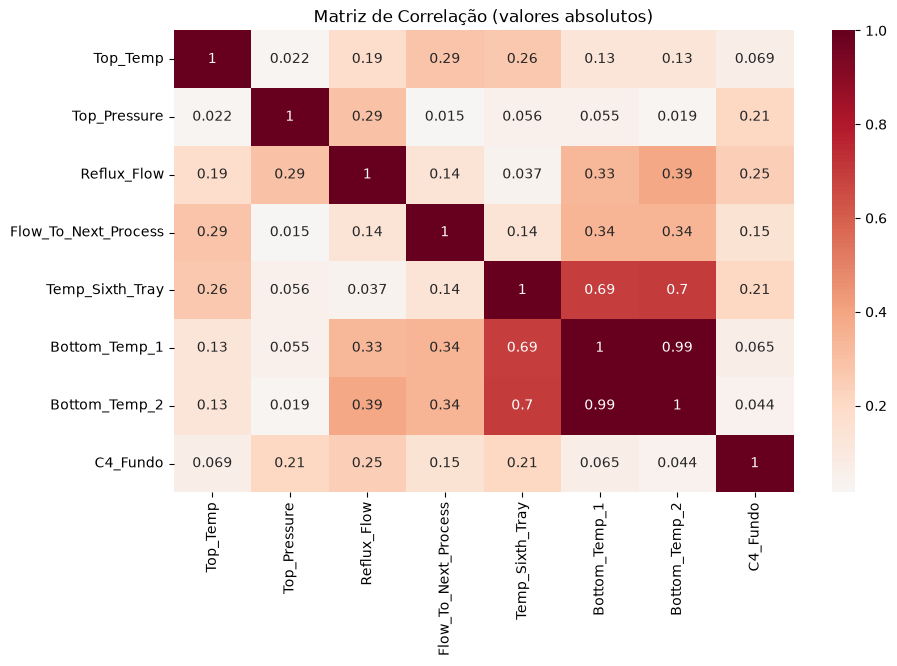

In [5]:
# Matriz de Correlação

plt.figure(figsize=(10, 6))
sns.heatmap(abs(df.corr()), annot=True, cmap='RdBu_r', center=0)
plt.title("Matriz de Correlação (valores absolutos)")
plt.show()

Com base na matriz de correlação de valores absolutos, podemos observar o seguinte:

**Relação com a Variável Alvo (`C4_Fundo`):**
*   A variável `C4_Fundo` (teor de C4 no fundo) apresenta as correlações mais fortes (ainda que moderadas) com `Reflux_Flow` (0.25), `Top_Sixth_Tray` (0,21) e `Top_Pressure` (0.21). As outras variáveis de temperatura, como  `Top_Temp`, `Bottom_Temp_1` e `Bottom_Temp_2`, mostram correlações diretas muito fracas (abaixo de 0.1) com `C4_Fundo`.
*   Isso sugere que a relação entre as variáveis de processo e o teor de C4 no fundo pode ser **não-linear** ou envolver **atrasos temporais significativos**, que uma correlação linear instantânea simples não captura . É um indicativo de que modelos mais sofisticados, que consideram dinâmicas e não-linearidades (como o PLS e modelos com *feature engineering* de janelas móveis e atrasos, que serão explorados posteriormente), serão mais adequados.

**Multicolinearidade entre Variáveis de Entrada:**
*   **Extrema Colinearidade:** `Bottom_Temp_1` e `Bottom_Temp_2` apresentam uma correlação extremamente alta (0.99). Uma vez que ambos os sensores estão localizados no fundo da coluna, em posições próximas, elas se comportam de maneira muito parecida.  
*   **Forte Colinearidade:** `Temp_Sixth_Tray` também é fortemente correlacionada com `Bottom_Temp_1` (0.69) e `Bottom_Temp_2` (0.70). Isso é esperado, pois são todas temperaturas em diferentes bandejas da coluna, que tendem a seguir um perfil térmico.
*   **Colinearidade Moderada:** Existem correlações moderadas entre outras variáveis, como `Reflux_Flow` com `Bottom_Temp_2` (0.39) e `Top_Pressure` com `Reflux_Flow` (0.29). Essas inter-relações são comuns em processos industriais acoplados.

 **Implicações**:
*   A presença de **alta multicolinearidade** entre as variáveis de entrada reforça a necessidade de técnicas de modelagem que consigam lidar com isso, como a Regressão por Componentes Principais (PCA) ou **Partial Least Squares (PLS)**.
*   As **baixas correlações diretas** com `C4_Fundo` indicam que um modelo simples de regressão linear pode não ser suficiente para capturar a complexidade da relação entre as entradas e a saída, justificando a exploração de *feature engineering* e modelos não-lineares.

### Verificação de Valores Nulos ou Duplicados

Vamos verificar a presença de valores nulos e linhas duplicadas:

In [6]:

# 1. Verificar valores nulos (NaN)
print("Valores ausentes por coluna:")
print(df.isnull().sum())

# 2. Verificar duplicatas (podem indicar erro de log/comunicação)
print(f"\nLinhas duplicadas: {df.duplicated().sum()}")

Valores ausentes por coluna:
Top_Temp                0
Top_Pressure            0
Reflux_Flow             0
Flow_To_Next_Process    0
Temp_Sixth_Tray         0
Bottom_Temp_1           0
Bottom_Temp_2           0
C4_Fundo                0
dtype: int64

Linhas duplicadas: 0


### Análise de "Sensores Travados" (Frozen Sensors)

Em sistemas industriais, uma falha comum não é o dado faltante, mas o sensor que trava em um valor constante enquanto o processo deveria estar variando. Vamos, então,verificar se existem sequências de 5 valores idênticos nas variáveis de entrada:

In [7]:
# Verificar se alguma variável ficou 'estática' por muito tempo
# Mostra o desvio padrão de janelas móveis; se for 0, o sensor travou
colunas_alerta=[]

for col in df.columns:
    if df[col].rolling(window=5).std().min() == 0:
        colunas_alerta.append(col)
        print(f"Alerta: Possível sensor travado na coluna {col}")

Alerta: Possível sensor travado na coluna Top_Temp
Alerta: Possível sensor travado na coluna Flow_To_Next_Process
Alerta: Possível sensor travado na coluna Bottom_Temp_2


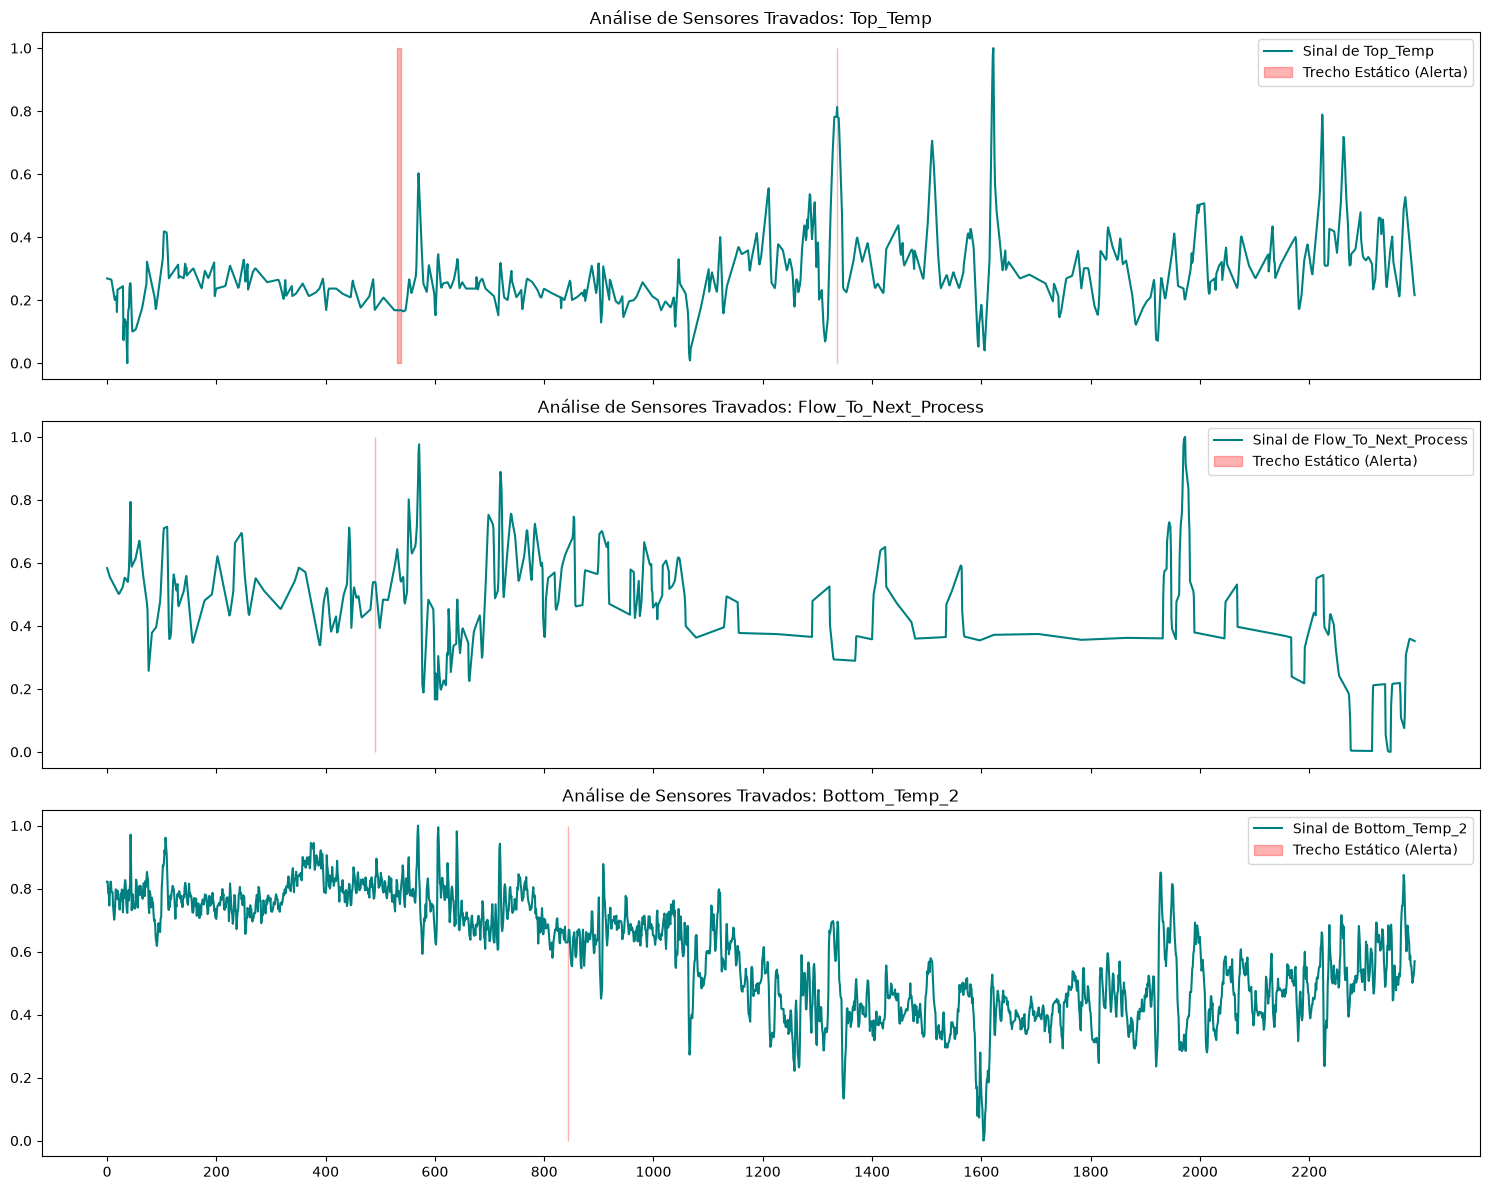

In [9]:
fig, axes = plt.subplots(nrows=len(colunas_alerta), ncols=1, figsize=(15, 12), sharex=True)

for i, col in enumerate(colunas_alerta):
    axes[i].plot(df.index, df[col], label=f'Sinal de {col}', color='teal')

    # Identificando visualmente onde o desvio padrão é zero
    is_frozen = df[col].rolling(window=5).std() == 0
    axes[i].fill_between(df.index, df[col].min(), df[col].max(),
                         where=is_frozen, color='red', alpha=0.3, label='Trecho Estático (Alerta)')

    axes[i].set_title(f"Análise de Sensores Travados: {col}")
    axes[i].legend()

ticks = np.arange(0, len(df), 200)
plt.xticks(ticks)


plt.tight_layout()
plt.show()

Analisamos se, em uma janela de 5 amostras temporais o desvio padrão é igual a 0, o que significaria que houve um congelamento do sinal lido pelo sensor. Embora algumas variáveis tenham apresentado essa característica, a baixa frequencia com que isso aconteceu não justifica o tratamento desses valores.

### Visualização de Continuidade

Vamos plotar as variáveis para identificar visualmente se há "degraus" (saltos bruscos) que sugiram que partes do histórico foram removidas ou se houve uma queda de energia no sistema de aquisição.

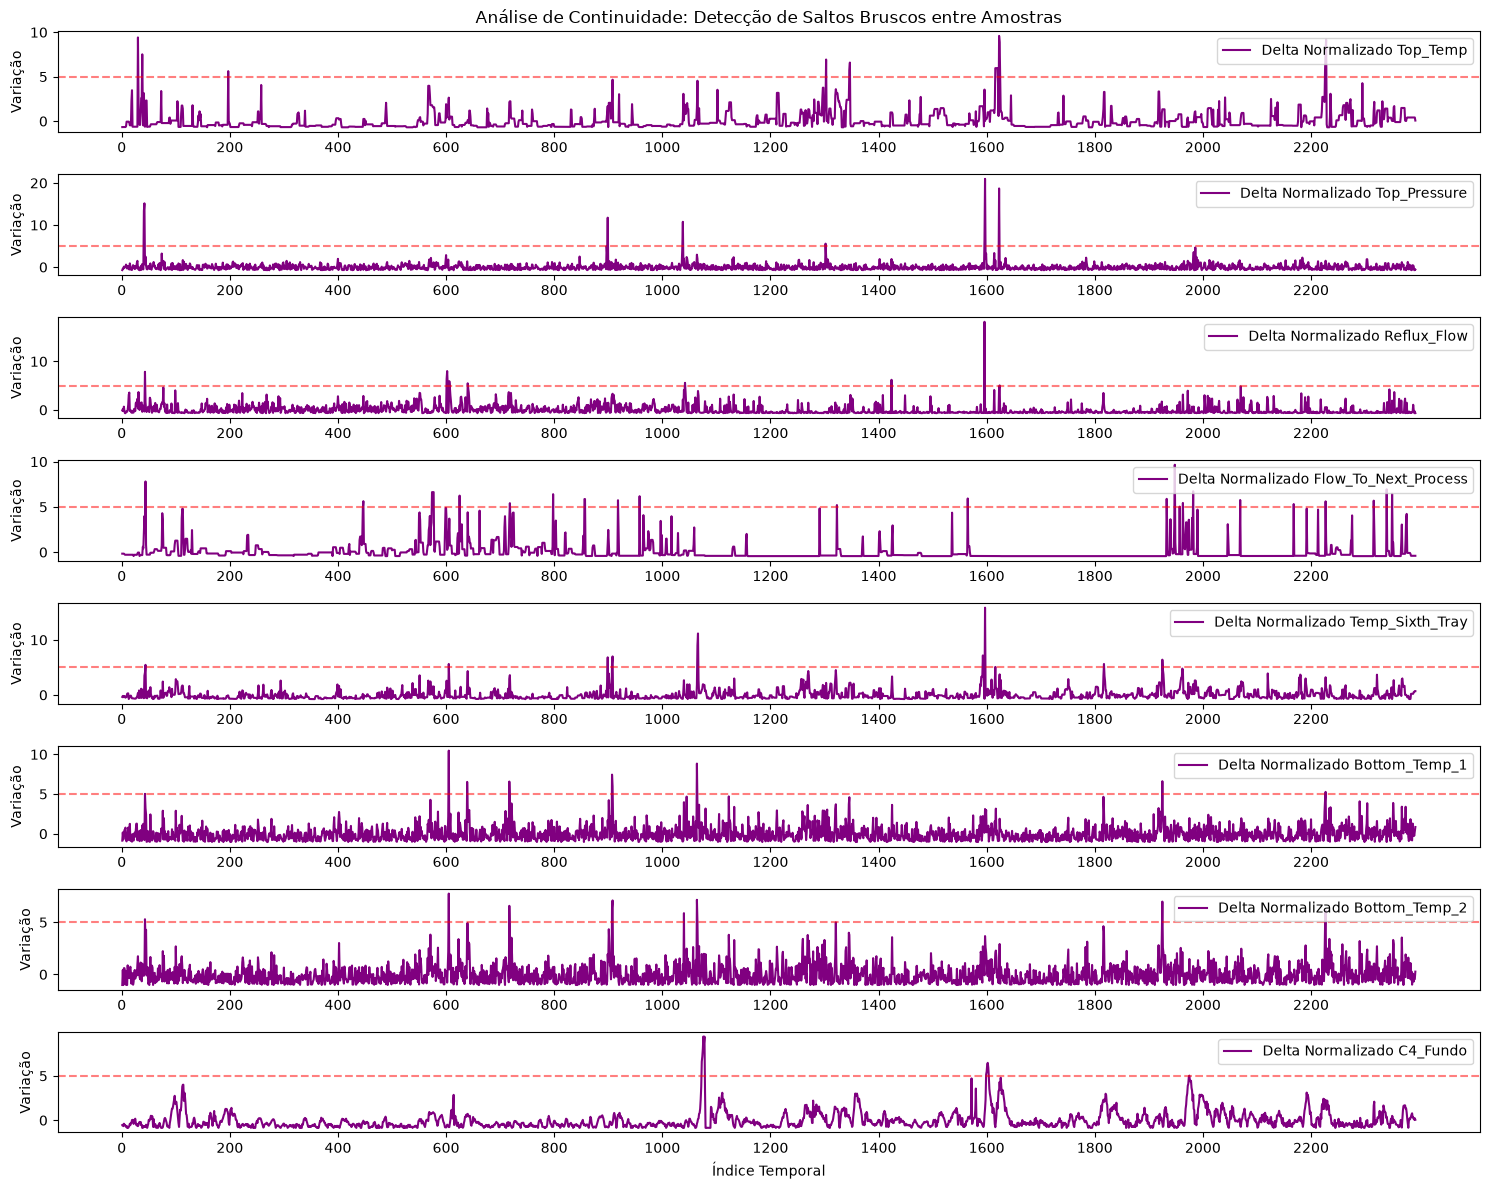

In [10]:
# Analisando o delta (variação) entre amostras consecutivas para todas as colunas
# Saltos muito grandes indicam perda de dados (time gaps)
plt.figure(figsize=(15, 12))

# Criamos a lista de marcas de 200 em 200 antes do loop 
ticks = np.arange(0, len(df), 200)

for i, col in enumerate(df.columns):
    plt.subplot(len(df.columns), 1, i+1)

    # Calculamos a variação absoluta entre amostras
    #Para cada coluna, o código calcula a diferença absoluta entre o valor atual e o valor da amostra imediatamente anterior

    delta = df[col].diff().abs()

    # Normalizamos o delta pelo desvio padrão para identificar saltos anômalos (Z-score de variação)
    #Como cada sensor mede coisas diferentes (ex: um mede vazão em $m^3/h$, outro mede temperatura em °C), não dá para usar um número fixo de alerta para todos.
    #Se z_delta for igual a 1, significa que aquela mudança está dentro da variação normal esperada
    z_delta = (delta - delta.mean()) / delta.std()

    plt.plot(df.index, z_delta, color='purple', label=f'Delta Normalizado {col}')

    # Linha vermelha de alerta para variações bruscas (> 5 desvios padrão)
    #uma variação maior que 5 desvios padrão em dados sequenciais é um evento extremamente raro e anômalo.
    #Quando a linha roxa do gráfico ultrapassa essa linha vermelha, significa que houve um salto brusco.
    plt.axhline(y=5, color='r', linestyle='--', alpha=0.5)

    plt.ylabel("Variação")
    plt.legend(loc='upper right')
    if i == 0:
        plt.title("Análise de Continuidade: Detecção de Saltos Bruscos entre Amostras")

    # --- AJUSTE EM TODOS OS SUBPLOTS ---
    # Aplica os ticks de 200 em 200 para o subplot atual
    plt.xticks(ticks)

    # Força o Matplotlib a exibir os números do eixo X, mesmo nos subplots de cima
    plt.gca().xaxis.set_tick_params(labelbottom=True)

plt.xlabel("Índice Temporal")
plt.tight_layout()
plt.show()

A plotagem temporal das variáveis de processo foi realizada para diagnosticar possíveis falhas de aquisição de dados (data gaps, quedas de energia no PIMS ou exclusões de trechos históricos).

Pode-se concluir que o dataset apresenta continuidade dinâmica estrita. Não foram observados 'degraus' artificiais ou descontinuidades matemáticas bruscas. Os eventos de mínima e máxima operacionais observados (como os vales próximos às amostras 0 e 1000) exibem o comportamento transiente e a inércia física típicos de distúrbios térmicos e hidráulicos reais de uma coluna de destilação, validando a série temporal para o treinamento do Soft Sensor.

### Processamento de Sinal (Filtragem por EMA e suavização de ruído)

Sensores industriais em ambiente de refinaria coletam ruídos de alta frequência causados por turbulência de fluidos, vibração de equipamentos e interferências elétricas na transmissão do sinal. 

Para mitigar esse efeito sem inserir um atraso de fase excessivo que comprometa o Soft Sensor, aplicou-se a **Média Móvel Exponencial (EMA)** com `span=18`. Esta abordagem é rigorosamente **causal** (utiliza apenas dados do presente e do passado), garantindo a viabilidade da aplicação do modelo em tempo real na malha de controle.

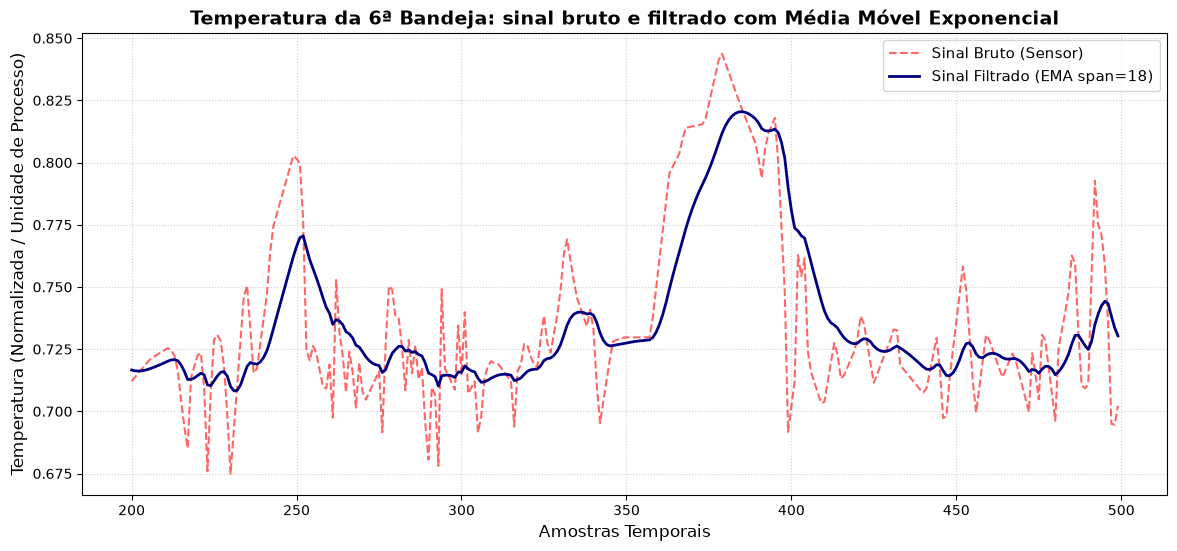

In [12]:
# 1. Vamos criar uma cópia para o dataframe 
df_processed = df.copy()

target = 'C4_Fundo'
features = [col for col in df.columns if col != target]

# 2. Aplicar a EMA com span=18 nas variáveis preditoras (colunas de sensores)

for col in features:
    df_processed[col] = df[col].ewm(span=18, adjust=False).mean()

# 3. Visualização do Efeito do Filtro 
plt.figure(figsize=(14, 6))

# Plot do sinal bruto
plt.plot(
    df["Temp_Sixth_Tray"].iloc[200:500],
    label="Sinal Bruto (Sensor)",
    color="red",
    alpha=0.6,
    linestyle="--",
)

# Plot do sinal filtrado
plt.plot(
    df_processed["Temp_Sixth_Tray"].iloc[200:500],
    label="Sinal Filtrado (EMA span=18)",
    color="navy",
    linewidth=2,
)

plt.title(
    "Temperatura da 6ª Bandeja: sinal bruto e filtrado com Média Móvel Exponencial",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Amostras Temporais", fontsize=12)
plt.ylabel("Temperatura (Normalizada / Unidade de Processo)", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11, loc="upper right")

plt.show()

O gráfico acima demonstra claramente a eficácia da Média Móvel Exponencial. O sinal tracejado em vermelho (Bruto) exibe micro-oscilações constantes (ruído de leitura). Podemos ver que o sinal em azul escuro (Filtrado por EMA) eliminou o ruído de alta frequência, preservando perfeitamente a tendência macro e a dinâmica de transição de temperatura da coluna. Por ser um filtro recursivo digital de primeira ordem, ele introduz um atraso de fase mínimo e controlado, ideal para o acoplamento com o preditor preditivo industrial.

### Análise de Estacionariedade

Dados de processos industriais contínuos podem apresentar comportamento não-estacionário devido a mudanças de carga, variações na temperatura ambiente ao longo do dia, ou degradação lenta de equipamentos (como incrustação em trocadores de calor). Para avaliar a estacionariedade das séries temporais, utilizou-se o teste estatístico **Augmented Dickey-Fuller (ADF)**. A aplicação de derivadas temporais discretas (`_deriv`) surge como uma solução para remover tendências e estacionarizar o sinal.  
Vamos aplicar o teste primeiramente à variavel `Bottom_Temp_2`para demonstrar a questão:

--- Teste ADF para: Bottom_Temp_2 (Nível) ---
Estatística ADF: -1.9993
p-valor: 0.2869
A série é estacionária? Não

--- Teste ADF para: Bottom_Temp_2_deriv (Derivada) ---
Estatística ADF: -12.1977
p-valor: 0.0000
A série é estacionária? Sim



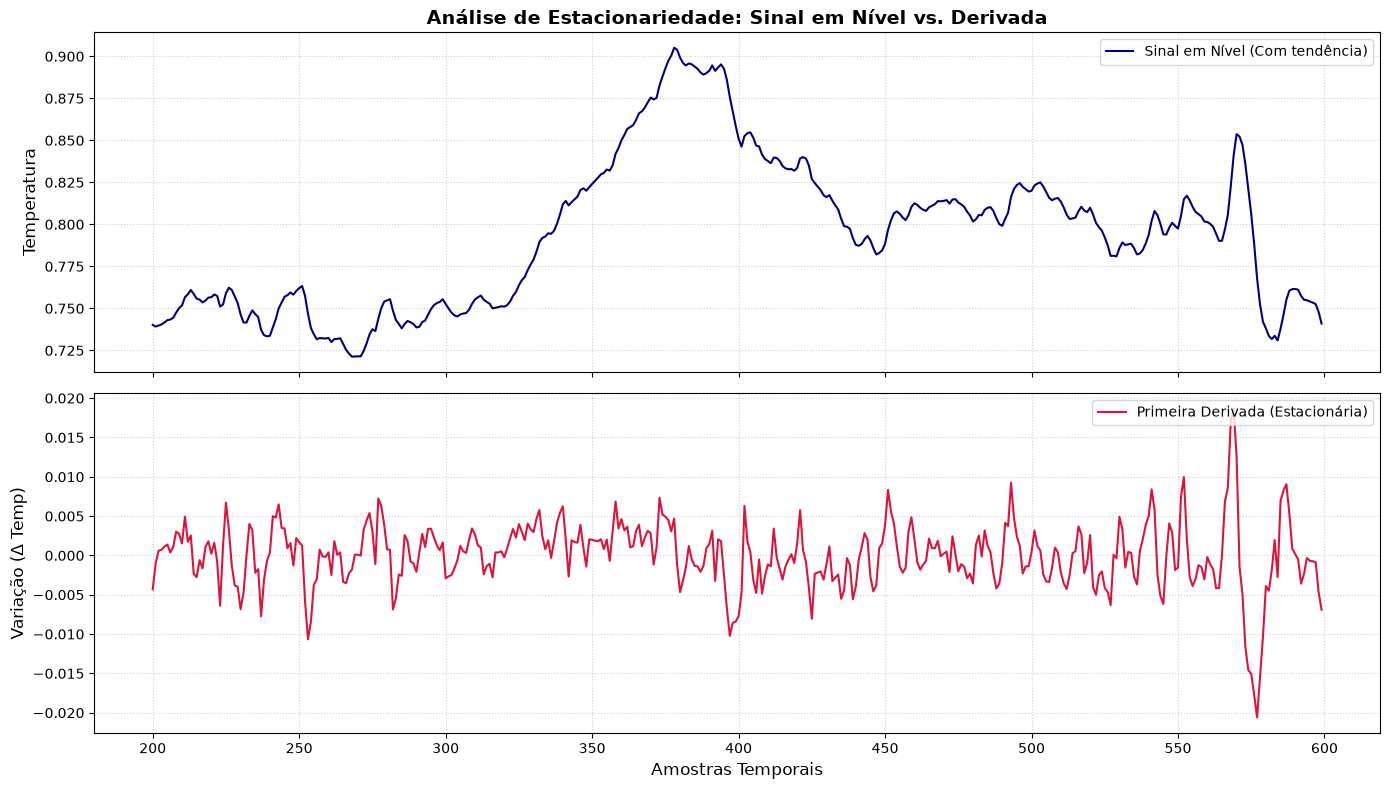

In [13]:
# 1. Calcular a derivada (Diferença finita de 1ª ordem)
# O pandas faz isso nativamente com o método .diff()
df_processed["Bottom_Temp_2_deriv"] = df_processed["Bottom_Temp_2"].diff()


# 2. Função para rodar o teste ADF e retornar o diagnóstico
def testar_estacionariedade(serie, nome_variavel):
    # Remove valores nulos gerados pelo diff() se houver
    resultado_adf = adfuller(serie.dropna())
    p_valor = resultado_adf[1]
    estacionaria = "Sim" if p_valor < 0.05 else "Não"

    print(f"--- Teste ADF para: {nome_variavel} ---")
    print(f"Estatística ADF: {resultado_adf[0]:.4f}")
    print(f"p-valor: {p_valor:.4f}")
    print(f"A série é estacionária? {estacionaria}\n")


# Executar o teste nas duas versões
testar_estacionariedade(df_processed["Bottom_Temp_2"], "Bottom_Temp_2 (Nível)")
testar_estacionariedade(
    df_processed["Bottom_Temp_2_deriv"], "Bottom_Temp_2_deriv (Derivada)"
)

# 3. Visualização Comparativa (Storytelling Visual)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Gráfico 1: Série em Nível (Original/Filtrada)
ax1.plot(
    df_processed["Bottom_Temp_2"].iloc[200:600],
    color="navy",
    label="Sinal em Nível (Com tendência)",
)
ax1.set_title(
    "Análise de Estacionariedade: Sinal em Nível vs. Derivada",
    fontsize=14,
    fontweight="bold",
)
ax1.set_ylabel("Temperatura", fontsize=12)
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(loc="upper right")

# Gráfico 2: Série Diferenciada (Derivada)
ax2.plot(
    df_processed["Bottom_Temp_2_deriv"].iloc[200:600],
    color="crimson",
    label="Primeira Derivada (Estacionária)",
)
ax2.set_ylabel("Variação ($\Delta$ Temp)", fontsize=12)
ax2.set_xlabel("Amostras Temporais", fontsize=12)
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

* Podemos observar no gráfico superior que a média do sinal não é constante; ela migra e muda de patamar ao longo do tempo. O teste ADF confirmou a não-estacionariedade da série original ($p = 0,2869$). Fisicamente, isso pode refletir a alta capacitância térmica do refervedor e o acúmulo de distúrbios de longo prazo (como variações lentas na carga de alimentação ou incrustação térmica), que causam uma 'deriva' (drift) na média do sinal. 
* A aplicação da primeira diferença removeu com sucesso a tendência estocástica de longo prazo, estacionarizando a série de forma estrita ($p = 0,0000$).

Este resultado alerta quanto a possível necessidade de expansão da nossa matriz com termos diferenciais (`_deriv`).

Vamos analisar as demais features:

In [14]:
# Lista com todas as suas variáveis preditoras (após filtro EMA)
features = ["Top_Temp", "Top_Pressure", "Reflux_Flow", "Flow_To_Next_Process", "Temp_Sixth_Tray", "Bottom_Temp_1"]

resultados_estacionariedade = []

for col in features:
    # Teste para o sinal em Nível
    res_nivel = adfuller(df_processed[col].dropna())
    p_nivel = res_nivel[1]
    
    # Teste para a Primeira Derivada
    res_deriv = adfuller(df_processed[col].diff().dropna())
    p_deriv = res_deriv[1]
    
    resultados_estacionariedade.append({
        "Variável": col,
        "p-valor (Nível)": round(p_nivel, 4),
        "Estacionária (Nível)?": "Sim" if p_nivel < 0.05 else "Não",
        "p-valor (Derivada)": round(p_deriv, 4),
        "Estacionária (Derivada)?": "Sim" if p_deriv < 0.05 else "Não"
    })

# Converter em DataFrame para exibição limpa
df_resumo_adf = pd.DataFrame(resultados_estacionariedade)
print("Resumo do Teste de Estacionariedade (ADF):")
print(df_resumo_adf.to_string(index=False))

Resumo do Teste de Estacionariedade (ADF):
            Variável  p-valor (Nível) Estacionária (Nível)?  p-valor (Derivada) Estacionária (Derivada)?
            Top_Temp           0.0023                   Sim                 0.0                      Sim
        Top_Pressure           0.0001                   Sim                 0.0                      Sim
         Reflux_Flow           0.0018                   Sim                 0.0                      Sim
Flow_To_Next_Process           0.0001                   Sim                 0.0                      Sim
     Temp_Sixth_Tray           0.0004                   Sim                 0.0                      Sim
       Bottom_Temp_1           0.0496                   Sim                 0.0                      Sim


Para as demais features, vemos que as variáveis já podem ser consideradas estacionárias, pelo Teste ADF. Isso pode ocorrer devido a natureza do processo industrial, o qual ocorre sob controle regulatório (malhas fechadas) eficaz, onde os controladores PID locais impedem o sinal de divergir indefinidamente, forçando-o a oscilar ao redor de médias operacionais estabilizadas. No entando, a aplicação da primeira diferença diferenciou o sinal drasticamente ($p = 0,0000$), centralizando a média estritamente em zero, o que pode ser uma vantagem adicional para a modelagem.

### Identificação do Tempo de Morto (Dead Time) ou Atraso de Transporte

Para identificar o Tempo de Morto (Dead Time) ou Atraso de Transporte, analisamos a relação entre cada variável de entrada ($x$) e a variável de saída ($y$). O objetivo é responder a seguinte pergunta: "Se eu alterar a vazão de alimentação agora, quanto tempo leva para essa mudança ser detectada pelo analisador no fundo da coluna?"  
Na destilação, o atraso ocorre porque o fluido precisa percorrer fisicamente as bandejas da coluna até chegar ao sensor. Matematicamente, podemos estimar esse atraso através da Função de Correlação Cruzada (FCC), que calcula a correlação entre $x(t-k)$ e $y(t)$ para vários valores de $k$ (atrasos).  

$$r_{xy}(k) = \frac{\sum (x_{t-k} - \bar{x})(y_t - \bar{y})}{\sqrt{\sum (x_{t-k} - \bar{x})^2 \sum (y_t - \bar{y})^2}}$$


Tabela de Resumo dos Atrasos Dinâmicos:
                      Lag_Otimo  Corr_Maxima
Top_Temp                   11.0      -0.3825
Top_Pressure                0.0      -0.2572
Reflux_Flow                 3.0      -0.3230
Flow_To_Next_Process        0.0       0.1401
Temp_Sixth_Tray             9.0      -0.7441
Bottom_Temp_1              11.0      -0.2512
Bottom_Temp_2              11.0      -0.2334




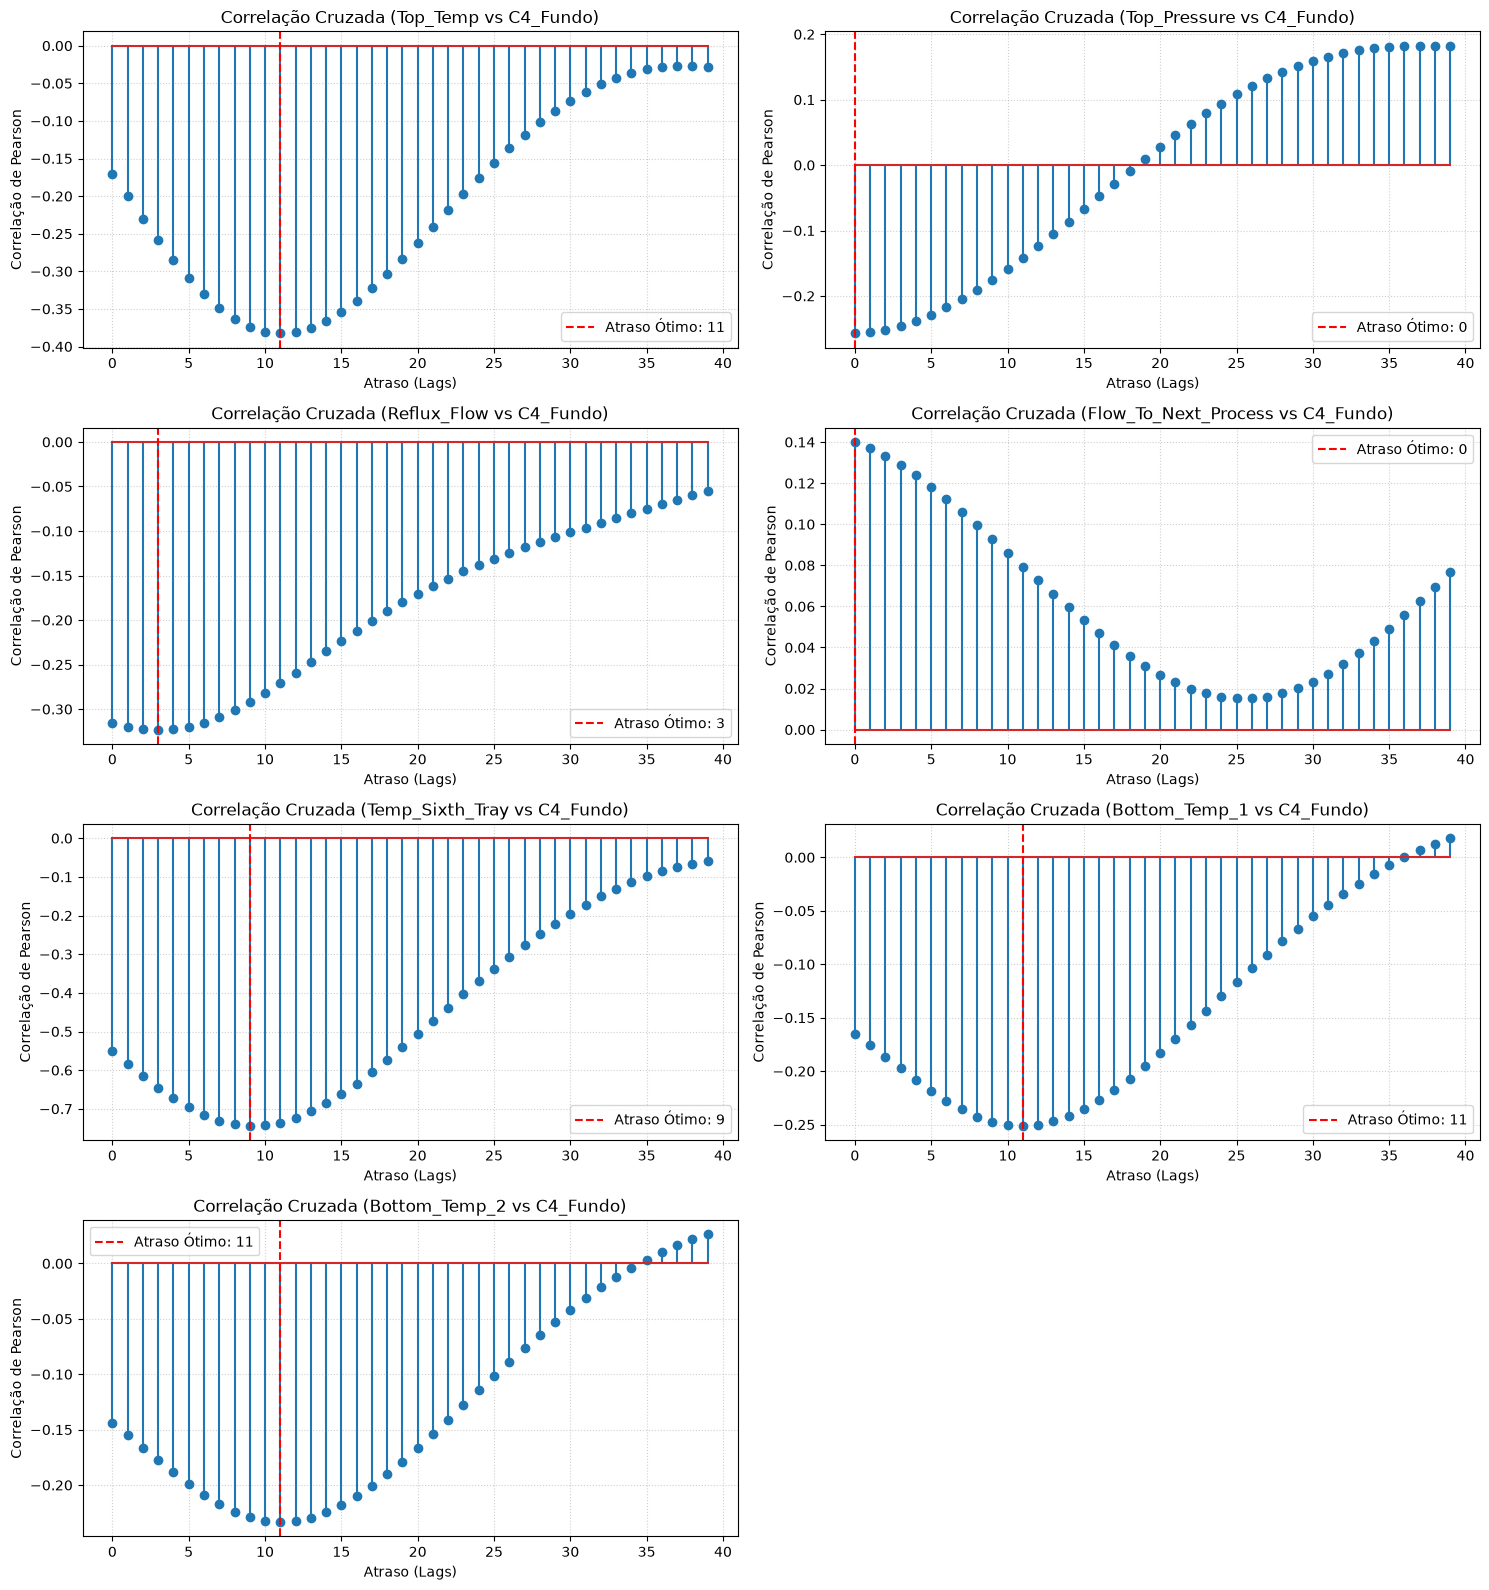

In [15]:
# 1. Configurações iniciais
lags = range(0, 40)  # Testando de 0 a 40 passos de atraso

features = [
    "Top_Temp",
    "Top_Pressure",
    "Reflux_Flow",
    "Flow_To_Next_Process",
    "Temp_Sixth_Tray",
    "Bottom_Temp_1",
    "Bottom_Temp_2",
]

# Dicionário para armazenar o resumo que alimentará a tabela
resumo_dados = {}
# Dicionário temporário para guardar todas as correlações para os gráficos
todas_correlacoes = {}

# 2. Primeiro Loop: Calcular correlações e estruturar o resumo
for col in features:
    correlations = []
    for lag in lags:
        corr = df_processed[col].shift(lag).corr(df[target])
        correlations.append(corr)
    
    # Salva as correlações calculadas para usar depois nos gráficos
    todas_correlacoes[col] = correlations
    
    # Encontrar o atraso ótimo e a correlação máxima (mantendo o sinal)
    maior_corr_idx = correlations.index(max(correlations, key=abs))
    atraso_otimo = lags[maior_corr_idx]
    corr_maxima = correlations[maior_corr_idx]
    
    # Armazena os resultados formatados
    resumo_dados[col] = {
        'Lag_Otimo': float(atraso_otimo),
        'Corr_Maxima': round(corr_maxima, 4)
    }

# 3. Exibir a Tabela de Resumo
df_resumo = pd.DataFrame.from_dict(resumo_dados, orient='index')
print("Tabela de Resumo dos Atrasos Dinâmicos:")
print(df_resumo)
print("\n" + "="*60 + "\n") # Linha separadora entre a tabela e os gráficos

# 4. Configuração do Grid de Subplots para os Gráficos
num_cols = 2
num_rows = math.ceil(len(features) / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 4 * num_rows))

if len(features) == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# 5. Segundo Loop: Renderização dos gráficos baseados no resumo anterior
for i, col in enumerate(features):
    correlations = todas_correlacoes[col]
    atraso_otimo = int(resumo_dados[col]['Lag_Otimo'])
    
    ax = axes[i]
    ax.stem(lags, correlations)
    ax.axvline(atraso_otimo, color='r', linestyle='--', label=f'Atraso Ótimo: {atraso_otimo}')
    ax.set_title(f"Correlação Cruzada ({col} vs {target})")
    ax.set_xlabel("Atraso (Lags)")
    ax.set_ylabel("Correlação de Pearson")
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)

# 6. Limpeza de eixos vazios (caso o número de features seja ímpar)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Como o intervalo de amostragem dos seus dados é de 12 minutos, cada unidade de `Lag_Otimo` equivale a 12 minutos de atraso físico no processo. Logo, se o lag ótimo para Reflux_Flow é igual a 3.0, isso quer dizer que uma mudança na Vazão de Refluxo produzirá efeitos máximos no fundo a partir de 36 minutos ($3 \times 12$).

- As variáveis `Flow_To_Next_Process` e `Top_Pressure` apresentaram lag igual a 0.0. Isso demonstra que distúrbios de pressão se propagam imediatamente (na velocidade do som) através da fase vapor da coluna. Da mesma forma, alterações na vazão de saída perturbam o balanço de massa e o nível de líquido de forma instantânea, exigindo respostas dinâmicas imediatas do sistema de controle.
- A vazão de refluxo (`Reflux_Flow`) apresentou um atraso de apenas 3 passos (36 minutos). Esse é o tempo que o líquido frio injetado no topo leva para escorrer pelos pratos superiores e alterar o perfil de temperatura interna da coluna.
- A variável `Temp_Sixth_Tray` teve sua correlação máxima fortalecida para -0,7441 após a filtragem, consolidando-se como o principal preditor termodinâmico do processo. O sinal negativo indica um ganho inverso: um aumento de temperatura na 6ª bandeja reduz o teor de C4_Fundo. 
- As variáveis `Bottom_Temp_1`, `Bottom_Temp_2` e `Top_Temp` compartilham o maior atraso dinâmico da tabela (Lag = 11.0, equivalente a 132 minutos ou 2,2 horas). Para as temperaturas de fundo, isso se justifica pela alta capacitância térmica do refervedor, que armazena um grande volume de líquido e leva mais tempo para estabilizar. O fato de a temperatura do topo (Top_Temp) compartilhar exatamente o mesmo lag de 11 passos evidencia o forte acoplamento térmico global do perfil de vapor da coluna debutanizadora.

### Matriz de Correlação após filtro EMA e alinhamento temporal

Agora que temos os dados filtrados pela Média Móvel Exponencial e após a realização do alinhamento temporal a partir dos resultados obtidos pela FCC, vamos analisar novamente a correlação entre as variáveis:

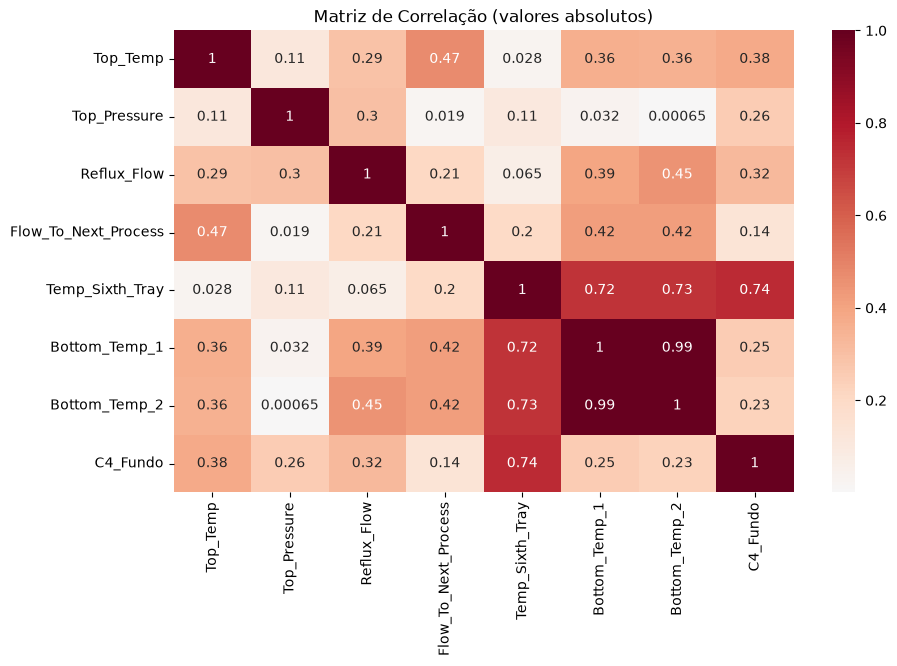

In [16]:
lags_ccf = {
    'Top_Temp': 11,
    'Top_Pressure': 0,
    'Reflux_Flow': 3,
    'Flow_To_Next_Process': 0,
    'Temp_Sixth_Tray': 9,
    'Bottom_Temp_1': 11,
    'Bottom_Temp_2': 11
}

df_aligned = df_processed[features].copy()
df_aligned['C4_Fundo'] = df['C4_Fundo']

for col, lag in lags_ccf.items():
    if lag > 0:
        df_aligned[col] = df_aligned[col].shift(lag)

# Matriz de Correlação

plt.figure(figsize=(10, 6))
sns.heatmap(abs(df_aligned.corr()), annot=True, cmap='RdBu_r', center=0)
plt.title("Matriz de Correlação (valores absolutos)")
plt.show()

A comparação entre a matriz de correlação bruta e a matriz pós-processamento demonstra a importância da engenharia de atributos. O tratamento de sinal por EMA eliminou a interferência de alta frequência dos sensores de campo, enquanto o alinhamento temporal por lags compensou o tempo morto hidráulico e térmico da coluna. Esse par de passos elevou o coeficiente de correlação linear da variável chave (`Temp_Sixth_Tray`) contra o alvo. Podemos ver também a relevância das variáveis `Top_Temp` e `Reflux_Flow`, cujos coeficientes de correlação passaram para 0.38 e 0.32.

### Mapeamento de Relações Não-Lineares

Fenômenos termodinâmicos de equilíbrio líquido-vapor em colunas de destilação frequentemente exibem comportamentos não-lineares sutis devido às pressões de vapor e coeficientes de atividade dos componentes.

Para expandir a capacidade dos modelos sem recorrer a arquiteturas de caixa-preta não-lineares (como redes neurais), avaliou-se visualmente a presença de curvaturas nas relações entre os principais preditores e a variável alvo. Essa análise serve para justificar a inclusão de termos polinomiais de segunda ordem (`_sq`) na matriz de atributos.  



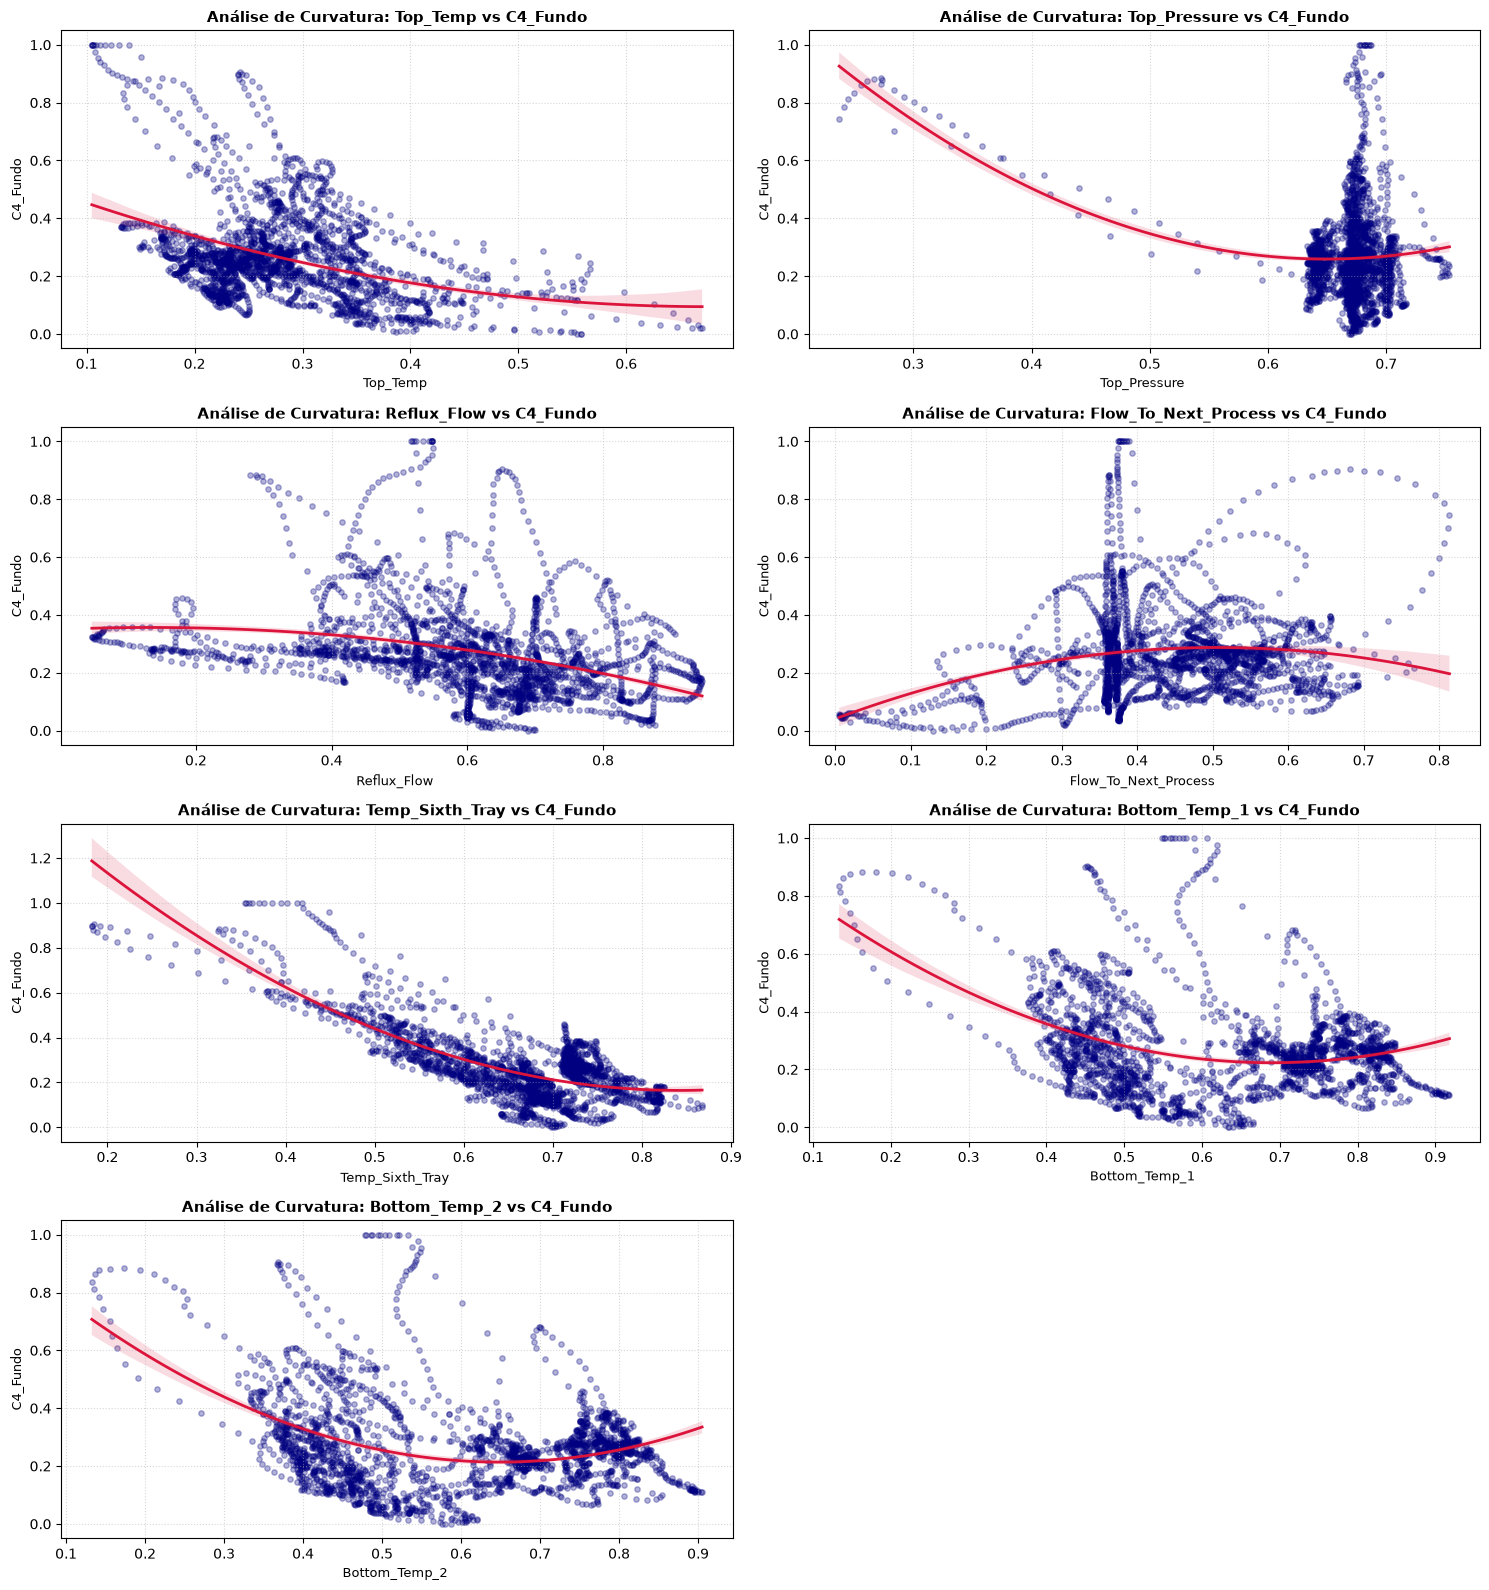

In [18]:
num_cols = 2
num_rows = math.ceil(len(features) / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 4 * num_rows))
axes = axes.flatten()

# Garantir que o df_aligned esteja limpo para o ajuste
df_plot_total = df_aligned.dropna()

for i, col in enumerate(features):
    ax = axes[i]
    
    # Gráfico de dispersão com ajuste de 2ª ordem para cada sensor
    sns.regplot(
        data=df_plot_total,
        x=col,
        y="C4_Fundo",
        scatter_kws={"alpha": 0.3, "color": "navy", "s": 15},
        line_kws={"color": "crimson", "linewidth": 2, "label": "Quadrático (Grau 2)"},
        order=2,
        truncate=True,
        ax=ax
    )
    
    ax.set_title(f"Análise de Curvatura: {col} vs C4_Fundo", fontsize=11, fontweight='bold')
    ax.set_xlabel(f"{col} ", fontsize=9)
    ax.set_ylabel("C4_Fundo", fontsize=9)
    ax.grid(True, linestyle=":", alpha=0.5)

# Remover subplots vazios se o número de features for ímpar
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

O ajuste polinomial acima foi realizado sobre o espaço de estados (Feature vs Target) com o objetivo exclusivo de diagnosticar não-linearidades estáticas e justificar a expansão polinomial da matriz de atributos (`_sq`). Este ajuste não deve ser interpretado como um modelo preditivo de séries temporais final, uma vez que a autocorrelação residual inerente aos dados sequenciais viola as premissas de independência dos mínimos quadrados ordinários (OLS).